<a href="https://colab.research.google.com/github/shubhamchau222/AIAgentsjourney/blob/main/Knowledge_Distillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

In [9]:
true_label= np.array([1,0,0])
pred_label= np.array([0.37, 0.50, 0.13]) #np.sum(pred_label)

# true label class
true_class= np.argmax(true_label)
print(true_class)

pred_class= np.argmax(pred_label)
print(pred_class)


0
1


## Cross entropy loss

In [13]:
epsilon = 1e-9
-np.sum(true_label * np.log(pred_label + epsilon))

np.float64(0.9942522706411642)

In [14]:
## using pytorch

import torch
import torch.nn.functional as F

probs = torch.tensor([[0.37, 0.50, 0.13]])

# Convert probabilities to logits using log
logits = torch.log(probs)

# True label (as class index, not one-hot)
target = torch.tensor([0])  # class 0 is the correct label

# Cross Entropy Loss
loss = F.cross_entropy(logits, target)
print("PyTorch Cross-Entropy Loss:", loss.item())


PyTorch Cross-Entropy Loss: 0.9942522644996643


# Teacher model building

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [17]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [31]:
train_data= datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data= datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# data loaders
train_loader=DataLoader(train_data, batch_size=64, shuffle=True)
test_loader=DataLoader(test_data, batch_size=64, shuffle=False )



In [33]:
import matplotlib.pyplot as plt
images, labels= next(iter(train_loader))
print(images.shape), labels

torch.Size([64, 1, 28, 28])


(None,
 tensor([9, 9, 2, 2, 1, 8, 5, 2, 8, 6, 1, 6, 8, 3, 3, 6, 6, 7, 8, 8, 4, 0, 6, 6,
         5, 1, 2, 7, 8, 2, 8, 2, 2, 8, 0, 6, 4, 4, 4, 6, 6, 0, 0, 9, 6, 3, 5, 3,
         3, 0, 9, 7, 3, 3, 7, 3, 6, 8, 2, 3, 2, 5, 2, 4]))

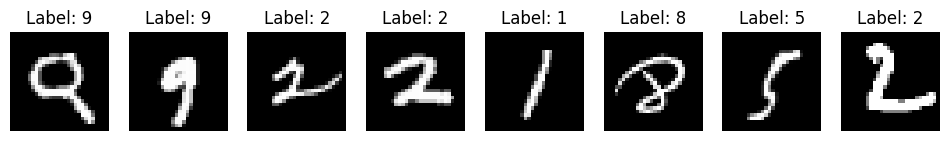

In [37]:
fig, axes= plt.subplots(1, 8, figsize=(12,4))
for i in range(8):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')

In [39]:
import torch
import torch.nn as nn

class Teacher(nn.Module):
  def __init__(self,hidden1=512, hidden2=256):
     super().__init__()

     self.net= nn.Sequential(
         nn.Flatten(),
         nn.Linear(28*28, hidden1),
         nn.ReLU(),
         nn.Linear(hidden1, hidden2),
         nn.ReLU(),
         nn.Linear(hidden2, 10) #10 output classes & Digits
     )

  def forward(self,x):
    return self.net(x)


In [41]:
# create instance
teacher= Teacher()
print(teacher)

Teacher(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [42]:
def train_teacher(model, loader, epochs, lr=1e-3):
  opt= optim.Adam(model.parameters(), lr=lr)
  loss_fn= nn.CrossEntropyLoss()
  model.train()

  for ep in range(epochs):
    total_loss=0
    for x, y in loader:
      opt.zero_grad()
      out= model(x)
      loss= loss_fn(out, y)
      loss.backward()
      opt.step()
      total_loss= total_loss + loss.item()
    print(f"Teacher loss at epoch {ep}: {total_loss/len(loader):.4f}")


In [43]:
train_teacher(teacher, train_loader, epochs=2)

Teacher loss at epoch 0: 0.2930
Teacher loss at epoch 1: 0.1356


In [45]:
# upadted weight
# teacher.state_dict()

In [48]:
# # ----------- Freeze teacher -----------
# for param in teacher.parameters():
#   param.retain_grad= False

# #----------- or -------------
# with torch.no_grad():
#   op = model(x)
# # --------- or -----------
# model.requires_grad_(False)
# teacher.eval()
# print("teacher model weight freezed")


| Method                                  | Freezes Parameters | Prevents Updates | Use Case                  |
| --------------------------------------- | ------------------ | ---------------- | ------------------------- |
| `param.requires_grad = False`           | ✅                  | ✅                | Most common               |
| `model.requires_grad_(False)`           | ✅                  | ✅                | Cleaner one-liner         |
| `with torch.no_grad()`                  | ❌                  | ✅                | Inference only            |
| `model.eval()`                          | ❌                  | ❌                | Disable dropout/batchnorm |
| Freeze submodule (e.g. `model.encoder`) | ✅                  | ✅                | Custom model freezing     |


In [50]:
# -------- Student Model (1 hidden layer) --------------
class Student(nn.Module):
  def __init__(self, hidden=128):
    super().__init__()
    self.net= nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28, hidden),
        nn.ReLU(),
        nn.Linear(hidden, 10)
    )
  def forward(self, x):
    return self.net(x)


In [51]:
student= Student()
print(student)

Student(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [53]:
def train_student(model, loader, epochs, lr=1e-3):
  opt= optim.Adam(model.parameters(), lr=lr)
  loss_fn= nn.CrossEntropyLoss()
  model.train()

  for ep in range(epochs):
    total_loss=0
    for x, y in loader:
      opt.zero_grad()
      out= model(x)
      loss= loss_fn(out, y)
      loss.backward()
      opt.step()
      total_loss= total_loss + loss.item()
    print(f"Teacher loss at epoch {ep}: {total_loss/len(loader):.4f}")



## ------------- Student warmup pretraining (optinal)------------------
# train_student(student, train_loader, epochs=1)

## Distillation

In [52]:
temperature=2.0
alpha=0.7
ce_loss= nn.CrossEntropyLoss()
kl_loss= nn.KLDivLoss(reduction='batchmean')
optimizer= optim.Adam(student.parameters(), lr=1e-3)

In [56]:
def distillation(student, teacher, loader, epochs=4):
  for ep in range(epochs):
    student.train()
    total_loss= 0
    for x , y in loader:
      # teacher output
      with torch.no_grad():
        teacher_logits = teacher(x)
        teacher_probs= torch.softmax(teacher_logits/temperature, dim=1)

      # student output
      student_logits= student(x)
      student_log_probs= torch.log_softmax(student_logits/temperature, dim=1)

      # losses
      loss_soft= kl_loss(student_log_probs, teacher_probs)
      loss_hard= ce_loss(student_logits, y)
      loss= alpha*loss_soft + (1-alpha)*loss_hard

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      total_loss= total_loss + loss.item()

    print(f"Student loss at epoch {ep}: {total_loss/len(loader):.4f}")



In [57]:
distillation(student, teacher, train_loader, epochs=4)

Student loss at epoch 0: 0.2798
Student loss at epoch 1: 0.1113
Student loss at epoch 2: 0.0701
Student loss at epoch 3: 0.0566


In [58]:
from functools import total_ordering
## Evaluate function

def evaluate(model, loader, name="model"):
  model.eval()
  correct, total= 0, 0
  with torch.no_grad():
    for x, y in loader:
      out= model(x)
      pred= torch.argmax(out, dim=1)
      correct_pred= (pred == y).sum().item()
      correct += correct_pred
      total += y.size(0)
  acc = (correct/total) * 100
  print(f"{name} accuracy: {acc:.2f}%")
  return acc


In [59]:
# Evaluate teacher model
evaluate(teacher, test_loader, "Teacher")

Teacher accuracy: 96.36%


96.36

In [60]:
# Evaluate student
evaluate(student, test_loader, "Student")

Student accuracy: 96.60%


96.6

In [61]:
## predictions
def pred(model,x):
  with torch.no_grad():
    op= model(x)
    return op.argmax(dim=1)


In [69]:
sample_batch, sample_labels= next(iter(test_loader))

## prediction
batch_predictions= pred(student, sample_batch)
print(batch_predictions)

tensor([7, 2, 1, 0, 4, 1, 4, 9, 6, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 2, 9, 2])


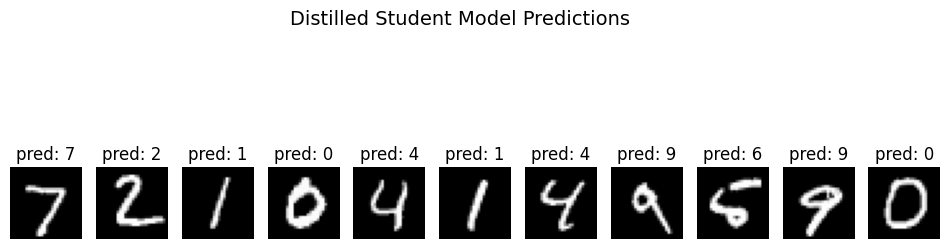

In [81]:
fig, axes= plt.subplots(1, 11, figsize=(12,4))
fig.suptitle("Distilled Student Model Predictions", fontsize=14)
for i in range(11):
    axes[i].imshow(sample_batch[i].squeeze(), cmap='gray')
    axes[i].set_title(f"pred: {batch_predictions[i].item()}")
    axes[i].axis('off')
plt.show()

## Save model

- Because state_dict only stores parameter tensors (like weights and biases), not the model's architecture or class. So PyTorch needs to know which architecture to load those weights into.

In [82]:
## Save the model
torch.save(student.state_dict(), "distilled_student.pth")
print("Student model saved as distilled_student.pth")

Student model saved as distilled_student.pth


In [97]:
## load model
#1. load model schema/architecture
#2. load saved model weight

studentLoadModel= Student()
studentLoadModel.load_state_dict(torch.load("distilled_student.pth"))
print(studentLoadModel)

with torch.no_grad():
  op= studentLoadModel(sample_batch)
  print(op.argmax(dim=1))
  print(batch_predictions == op.argmax(dim=1))

Student(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
tensor([7, 2, 1, 0, 4, 1, 4, 9, 6, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 2, 9, 2])
tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True])


## Save entire model with architecure + weights

In [105]:
import os
os.mkdir("./FullModel")

In [106]:
## save full model with weight & architecture
torch.save(student, "./FullModel/Full_model_with_architecure_and_weight.pth")
print("Student model saved as Full_model_with_architecure_and_weight.pth")

Student model saved as Full_model_with_architecure_and_weight.pth


In [108]:
loaded_model = torch.load("./FullModel/Full_model_with_architecure_and_weight.pth",
                          weights_only=False)
with torch.no_grad():
  op= loaded_model(sample_batch)
  print(op.argmax(dim=1))
  print(batch_predictions == op.argmax(dim=1))

tensor([7, 2, 1, 0, 4, 1, 4, 9, 6, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 2, 9, 2])
tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True])


## Experimentation

| What                       | How                                                                      |
| -------------------------- | ------------------------------------------------------------------------ |
| Model architecture         | Save as `.py` or text in `artifacts/`                                    |
| Model parameters (config)  | `mlflow.log_params()`                                                    |
| Model weights              | `mlflow.pytorch.log_model()`                                             |
| Training metrics           | `mlflow.log_metrics()`                                                   |
| Python script/code version | `mlflow.log_artifact("model.py")` or `mlflow.set_tag("git_commit", ...)` |


Logging **model architectures** to **MLflow** is crucial for reproducibility. Here's a full guide with **code** to help you log:

---

## ✅ What You’ll Log to MLflow

| What                       | How                                                                      |
| -------------------------- | ------------------------------------------------------------------------ |
| Model architecture         | Save as `.py` or text in `artifacts/`                                    |
| Model parameters (config)  | `mlflow.log_params()`                                                    |
| Model weights              | `mlflow.pytorch.log_model()`                                             |
| Training metrics           | `mlflow.log_metrics()`                                                   |
| Python script/code version | `mlflow.log_artifact("model.py")` or `mlflow.set_tag("git_commit", ...)` |

---

## 🧪 Example: Logging a PyTorch Model with Architecture

Let's say you have the following model and training setup:

### `model.py`

```python
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self, hidden_size=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 10)
        )

    def forward(self, x):
        return self.net(x)
```

---

### 🔁 Training + MLflow Logging Script

```python
import mlflow
import mlflow.pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from model import SimpleNN

# Example: dummy data
x = torch.randn(64, 784)
y = torch.randint(0, 10, (64,))

# Define model, loss, optimizer
model = SimpleNN(hidden_size=256, dropout=0.2)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Start MLflow run
with mlflow.start_run():
    # Log model config (architecture details)
    mlflow.log_params({
        "model_type": "SimpleNN",
        "hidden_size": 256,
        "dropout": 0.2,
        "lr": 0.001,
        "loss": "CrossEntropy"
    })

    # Train one step (just for example)
    preds = model(x)
    loss = loss_fn(preds, y)
    loss.backward()
    optimizer.step()

    # Log training metrics
    mlflow.log_metric("train_loss", loss.item())

    # Log full model weights
    mlflow.pytorch.log_model(model, "model")

    # Save and log the architecture code file (for reproducibility)
    mlflow.log_artifact("model.py")
```

---

## 🧠 How to Load Later

```python
import mlflow.pytorch

model = mlflow.pytorch.load_model("runs:/<run_id>/model")
```

> You can find `<run_id>` from the MLflow UI or CLI.

---

## 💡 Best Practices

| Tip                            | Description                                        |
| ------------------------------ | -------------------------------------------------- |
| 🔖 Use tags                    | `mlflow.set_tag("experiment", "dropout_test")`     |
| 🧾 Log config files            | `mlflow.log_artifact("config.yaml")`               |
| 🧠 Save model class separately | Always save architecture file (e.g., `model.py`)   |
| 🌍 Version control             | Use `mlflow.set_tag("git_commit", <hash>)`         |
| ☁️ Remote storage              | Set `MLFLOW_TRACKING_URI` to remote (e.g., S3, DB) |

---

## ✅ Bonus: Use MLflow Projects

If you want full reproducibility (including `conda.yaml`, `main.py`, configs), wrap your training script as an MLflow project.

Let me know if you'd like a template for that too.

---

Would you like me to also integrate this with:

* **Hydra config system**
* **Weights & Biases**
* or **Databricks MLflow**?

Let me know your setup.
